In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [59]:
stats_1 = pd.read_csv("all_stats_vs_revenue_1.csv")
stats_2 = pd.read_csv("all_stats_vs_revenue_2.csv")


In [60]:
import pandas as pd
import numpy as np

# 读取两个CSV文件
stats_1 = pd.read_csv("all_stats_vs_revenue_1.csv")
stats_2 = pd.read_csv("all_stats_vs_revenue_2.csv")

print(f"stats_1 shape: {stats_1.shape}")
print(f"stats_2 shape: {stats_2.shape}")

# 找到重叠的起始点
# 方法1: 比较stats_2的第一行与stats_1中的所有行
def find_overlap_point(df1, df2, tolerance=1e-6):
    """
    找到df2的第一行在df1中的位置
    """
    first_row_df2 = df2.iloc[0]
    
    # 获取数值列进行比较
    numeric_cols = df1.select_dtypes(include=[np.number]).columns
    
    for i in range(len(df1)):
        # 比较数值列
        match = True
        for col in numeric_cols:
            if col in first_row_df2.index:
                if abs(df1.iloc[i][col] - first_row_df2[col]) > tolerance:
                    match = False
                    break
        
        if match:
            return i
    
    return None

# 查找重叠点
overlap_index = find_overlap_point(stats_1, stats_2)

if overlap_index is not None:
    print(f"找到重叠点在 stats_1 的索引: {overlap_index}")
    
    # 方法1: 直接拼接（从重叠点开始用stats_2替换）
    stats_combined_method1 = pd.concat([
        stats_1.iloc[:overlap_index],  # stats_1的前半部分（不包括重叠行）
        stats_2                        # 完整的stats_2
    ], ignore_index=True)
    
    print(f"方法1 - 合并后形状: {stats_combined_method1.shape}")
    
    # 方法2: 更保守的拼接（只添加stats_2中不重叠的部分）
    # 计算stats_1和stats_2的重叠长度
    overlap_length = len(stats_1) - overlap_index
    
    if overlap_length <= len(stats_2):
        # stats_2完全包含重叠部分，添加stats_2中超出的部分
        stats_combined_method2 = pd.concat([
            stats_1,                                    # 完整的stats_1
            stats_2.iloc[overlap_length:]              # stats_2中超出重叠的部分
        ], ignore_index=True)
    else:
        # 重叠部分超过了stats_2的长度
        stats_combined_method2 = stats_1  # 保持stats_1不变
    
    print(f"方法2 - 合并后形状: {stats_combined_method2.shape}")
    
    # 验证拼接结果
    print("\n=== 拼接验证 ===")
    print("重叠点附近的数据对比:")
    print("stats_1 重叠行:")
    print(stats_1.iloc[overlap_index:overlap_index+2])
    print("\nstats_2 开始行:")
    print(stats_2.iloc[:2])
    
    # 选择使用哪种方法
    stats = stats_combined_method1  # 通常使用方法1
    
else:
    print("未找到重叠点，尝试其他方法...")
    
    # 如果直接比较失败，尝试比较特定列
    # 假设有时间戳或唯一标识列
    if 'Unnamed: 0' in stats_1.columns and 'Unnamed: 0' in stats_2.columns:
        # 使用索引列查找重叠
        last_index_1 = stats_1['Unnamed: 0'].iloc[-1]
        first_index_2 = stats_2['Unnamed: 0'].iloc[0]
        
        if first_index_2 <= last_index_1:
            # 有重叠，找到具体位置
            overlap_mask = stats_1['Unnamed: 0'] >= first_index_2
            overlap_start = stats_1[overlap_mask].index[0]
            
            stats = pd.concat([
                stats_1.iloc[:overlap_start],
                stats_2
            ], ignore_index=True)
            
            print(f"基于索引列找到重叠，合并后形状: {stats.shape}")
        else:
            # 无重叠，直接拼接
            stats = pd.concat([stats_1, stats_2], ignore_index=True)
            print(f"无重叠，直接拼接，合并后形状: {stats.shape}")
    else:
        # 最后的备选方案：直接拼接
        stats = pd.concat([stats_1, stats_2], ignore_index=True)
        print(f"直接拼接，合并后形状: {stats.shape}")

# 清理合并后的数据
if 'Unnamed: 0' in stats.columns:
    stats = stats.drop('Unnamed: 0', axis=1)

# 重置索引
stats = stats.reset_index(drop=True)

print(f"\n最终合并数据形状: {stats.shape}")
print("\n合并后数据预览:")
print(stats.head())
print("\n...")
print(stats.tail())

# 检查数据完整性
print(f"\n=== 数据完整性检查 ===")
print(f"总行数: {len(stats)}")
print(f"缺失值统计:")
print(stats.isnull().sum())

# 如果有revenues列，显示基本统计
if 'revenues' in stats.columns:
    print(f"\nrevenues列统计:")
    print(f"  总收益: {stats['revenues'].sum():.6f}")
    print(f"  平均收益: {stats['revenues'].mean():.6f}")
    print(f"  收益标准差: {stats['revenues'].std():.6f}")

stats_1 shape: (639402, 11)
stats_2 shape: (539402, 11)
找到重叠点在 stats_1 的索引: 600000
方法1 - 合并后形状: (1139402, 11)
方法2 - 合并后形状: (1139402, 11)

=== 拼接验证 ===
重叠点附近的数据对比:
stats_1 重叠行:
             stats_1    stats_2   stats_3       stats_4   stats_5   stats_6  \
600000 -12342.934756  31.313333  1.578768  1.257097e+06  0.725538  0.068050   
600001 -11956.163048  31.314788  1.618036  1.257309e+06  0.725171  0.068916   

         stats_7   stats_8   stats_9      stats_10   revenues  
600000  0.764772  0.197049  4.251905  19651.132387  23.425274  
600001  0.764355  0.907361  4.217713  18241.623105  24.263157  

stats_2 开始行:
        stats_1    stats_2   stats_3       stats_4   stats_5   stats_6  \
0 -12342.934756  31.313333  1.578768  1.257097e+06  0.725538  0.068050   
1 -11956.163048  31.314788  1.618036  1.257309e+06  0.725171  0.068916   

    stats_7   stats_8   stats_9      stats_10   revenues  
0  0.764772  0.197049  4.251905  19651.132387  23.425274  
1  0.764355  0.907361  4.217713  18241.

In [61]:
stats

,stats_1,stats_2,stats_3,stats_4,stats_5,stats_6,stats_7,stats_8,stats_9,stats_10,revenues
0,-9659.436314,31.676654,4.179952,2.619471e+05,0.389767,0.119052,0.371009,-0.193642,4.634380,999236.720395,-2.538876
1,-10378.355503,31.686585,3.918506,2.610480e+05,0.389313,0.116785,0.370563,-0.625243,4.788858,983806.187187,-2.464805
2,-10101.836670,31.685810,3.889684,2.503120e+05,0.389580,0.114377,0.366220,-1.190992,4.441716,979684.067891,-0.753223
3,-10266.991472,31.681937,3.867600,2.504345e+05,0.390389,0.114029,0.366999,-2.017358,4.576838,979684.067891,-6.160408
4,-13014.091036,31.683914,3.853636,2.502650e+05,0.389982,0.113044,0.366815,-2.710301,4.679182,976125.912120,-5.418989
...,...,...,...,...,...,...,...,...,...,...,...
1139397,-10055.837126,30.787170,5.505391,2.922346e+06,0.716094,0.121548,0.779013,-0.070080,4.194409,227016.403051,-7.835400
1139398,-9801.852115,30.795945,5.192169,2.909048e+06,0.713145,0.115511,0.777319,0.349706,4.138160,227016.403078,-2.945540
1139399,-9852.879440,30.793262,4.957420,2.897974e+06,0.708851,0.107492,0.773911,1.081485,4.117222,227016.403051,-2.921117
1139400,-10606.878574,30.790334,4.820600,2.896043e+06,0.707637,0.104548,0.774039,0.904541,4.214835,227016.403047,-7.614233


In [62]:
stats['stats_11'] = abs(stats['stats_3'])

stats['stats_12'] = abs(stats['stats_6'])

stats['stats_13'] = abs(stats['stats_8'])

## Feature Engineering
- stats_1.append(objective_value)
- stats_2.append(coef_1_mean)
- stats_3.append(coef_2_mean)
- stats_4.append(coef_3_mean)
- stats_5.append(corr_1_mean)
- stats_6.append(corr_2_mean)
- stats_7.append(corr_3_mean)
- stats_8.append(cmi_mean)
- stats_9.append(cmi_std)
- stats_10.append(amihud_mean)

In [63]:
# 定义窗口大小列表
window_sizes = [25, 50, 200, 1000, 10000, 100000]
one_to_13 = list(range(1, 14))

# 循环生成移动平均列
for window in window_sizes:
  for i in one_to_13:
    stats[f'stats_{i}_MA_{window}'] = stats[f'stats_{i}'].rolling(window=window).mean()
    stats[f'stats_{i}_STD_{window}'] = stats[f'stats_{i}'].rolling(window=window).std()

  stats[f'revenues_MA_{window}'] = stats[f'revenues'].rolling(window=window).mean().shift(200)
  stats[f'revenues_STD_{window}'] = stats[f'revenues'].rolling(window=window).std().shift(200)
  

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_42800/3250186912.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stats[f'stats_{i}_MA_{window}'] = stats[f'stats_{i}'].rolling(window=window).mean()
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_42800/3250186912.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stats[f'stats_{i}_STD_{window}'] = stats[f'stats_{i}'].rolling(window=window).std()
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_42800/3250186912.py:8: PerformanceWarning: DataFram

In [64]:
two_to_13 = list(range(2, 14))
for i in two_to_13:
  stats[f'stats_{i}_to_stats_1_MA_10000'] = stats[f'stats_{i}'] / stats[f'stats_1'].rolling(window=10000).mean()

  stats[f'stats_{i}_to_stats_1_MA_100000'] = stats[f'stats_{i}'] / stats[f'stats_1'].rolling(window=100000).mean()
  


/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_42800/3522124801.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stats[f'stats_{i}_to_stats_1_MA_10000'] = stats[f'stats_{i}'] / stats[f'stats_1'].rolling(window=10000).mean()
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_42800/3522124801.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stats[f'stats_{i}_to_stats_1_MA_100000'] = stats[f'stats_{i}'] / stats[f'stats_1'].rolling(window=100000).mean()
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipyke

In [65]:
stats_valid = stats.iloc[100200:]

In [66]:
stats_valid

,stats_1,stats_2,stats_3,stats_4,stats_5,stats_6,stats_7,stats_8,stats_9,stats_10,...,stats_9_to_stats_1_MA_10000,stats_9_to_stats_1_MA_100000,stats_10_to_stats_1_MA_10000,stats_10_to_stats_1_MA_100000,stats_11_to_stats_1_MA_10000,stats_11_to_stats_1_MA_100000,stats_12_to_stats_1_MA_10000,stats_12_to_stats_1_MA_100000,stats_13_to_stats_1_MA_10000,stats_13_to_stats_1_MA_100000
100200,-21018.089619,32.788836,-1.067989,5.881516e+05,0.645847,0.026935,0.688472,21.374818,5.737063,26400.487357,...,-0.000441,-0.000427,-2.028056,-1.966311,-0.000082,-0.000080,-0.000002,-0.000002,-0.001642,-0.001592
100201,-21052.835679,32.790112,-0.800782,5.876300e+05,0.639034,0.041127,0.684243,20.155407,5.699814,26400.487356,...,-0.000438,-0.000425,-2.028094,-1.966301,-0.000062,-0.000060,-0.000003,-0.000003,-0.001548,-0.001501
100202,-21477.848385,32.790560,-0.943025,5.808661e+05,0.633976,0.035078,0.684077,20.174691,6.099768,26400.487356,...,-0.000469,-0.000454,-2.028125,-1.966290,-0.000072,-0.000070,-0.000003,-0.000003,-0.001550,-0.001503
100203,-22536.671619,32.785454,-0.970639,5.813770e+05,0.632159,0.035086,0.682047,20.655698,6.203783,26400.487356,...,-0.000477,-0.000462,-2.028118,-1.966279,-0.000075,-0.000072,-0.000003,-0.000003,-0.001587,-0.001538
100204,-22693.752799,32.786730,-0.970573,5.812708e+05,0.631156,0.036417,0.681243,19.888669,6.286243,26400.487356,...,-0.000483,-0.000468,-2.028109,-1.966266,-0.000075,-0.000072,-0.000003,-0.000003,-0.001528,-0.001481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139397,-10055.837126,30.787170,5.505391,2.922346e+06,0.716094,0.121548,0.779013,-0.070080,4.194409,227016.403051,...,-0.000400,-0.000383,-21.675602,-20.708580,-0.000526,-0.000502,-0.000012,-0.000011,-0.000007,-0.000006
1139398,-9801.852115,30.795945,5.192169,2.909048e+06,0.713145,0.115511,0.777319,0.349706,4.138160,227016.403078,...,-0.000395,-0.000377,-21.677699,-20.708712,-0.000496,-0.000474,-0.000011,-0.000011,-0.000033,-0.000032
1139399,-9852.879440,30.793262,4.957420,2.897974e+06,0.708851,0.107492,0.773911,1.081485,4.117222,227016.403051,...,-0.000393,-0.000376,-21.679622,-20.708826,-0.000473,-0.000452,-0.000010,-0.000010,-0.000103,-0.000099
1139400,-10606.878574,30.790334,4.820600,2.896043e+06,0.707637,0.104548,0.774039,0.904541,4.214835,227016.403047,...,-0.000403,-0.000384,-21.681317,-20.708925,-0.000460,-0.000440,-0.000010,-0.000010,-0.000086,-0.000083


In [67]:
# stats_training = stats_valid.iloc[:700000]
# stats_testing = stats_valid.iloc[700000:]

stats_training = stats_valid.iloc[300000:]
stats_testing = stats_valid.iloc[:300000]

In [68]:
X_training = stats_training.drop(columns=['revenues'])
y_training = stats_training['revenues']
X_testing = stats_testing.drop(columns=['revenues'])
y_testing = stats_testing['revenues']

In [69]:
X_training.shape, y_training.shape, X_testing.shape, y_testing.shape

((739202, 205), (739202,), (300000, 205), (300000,))

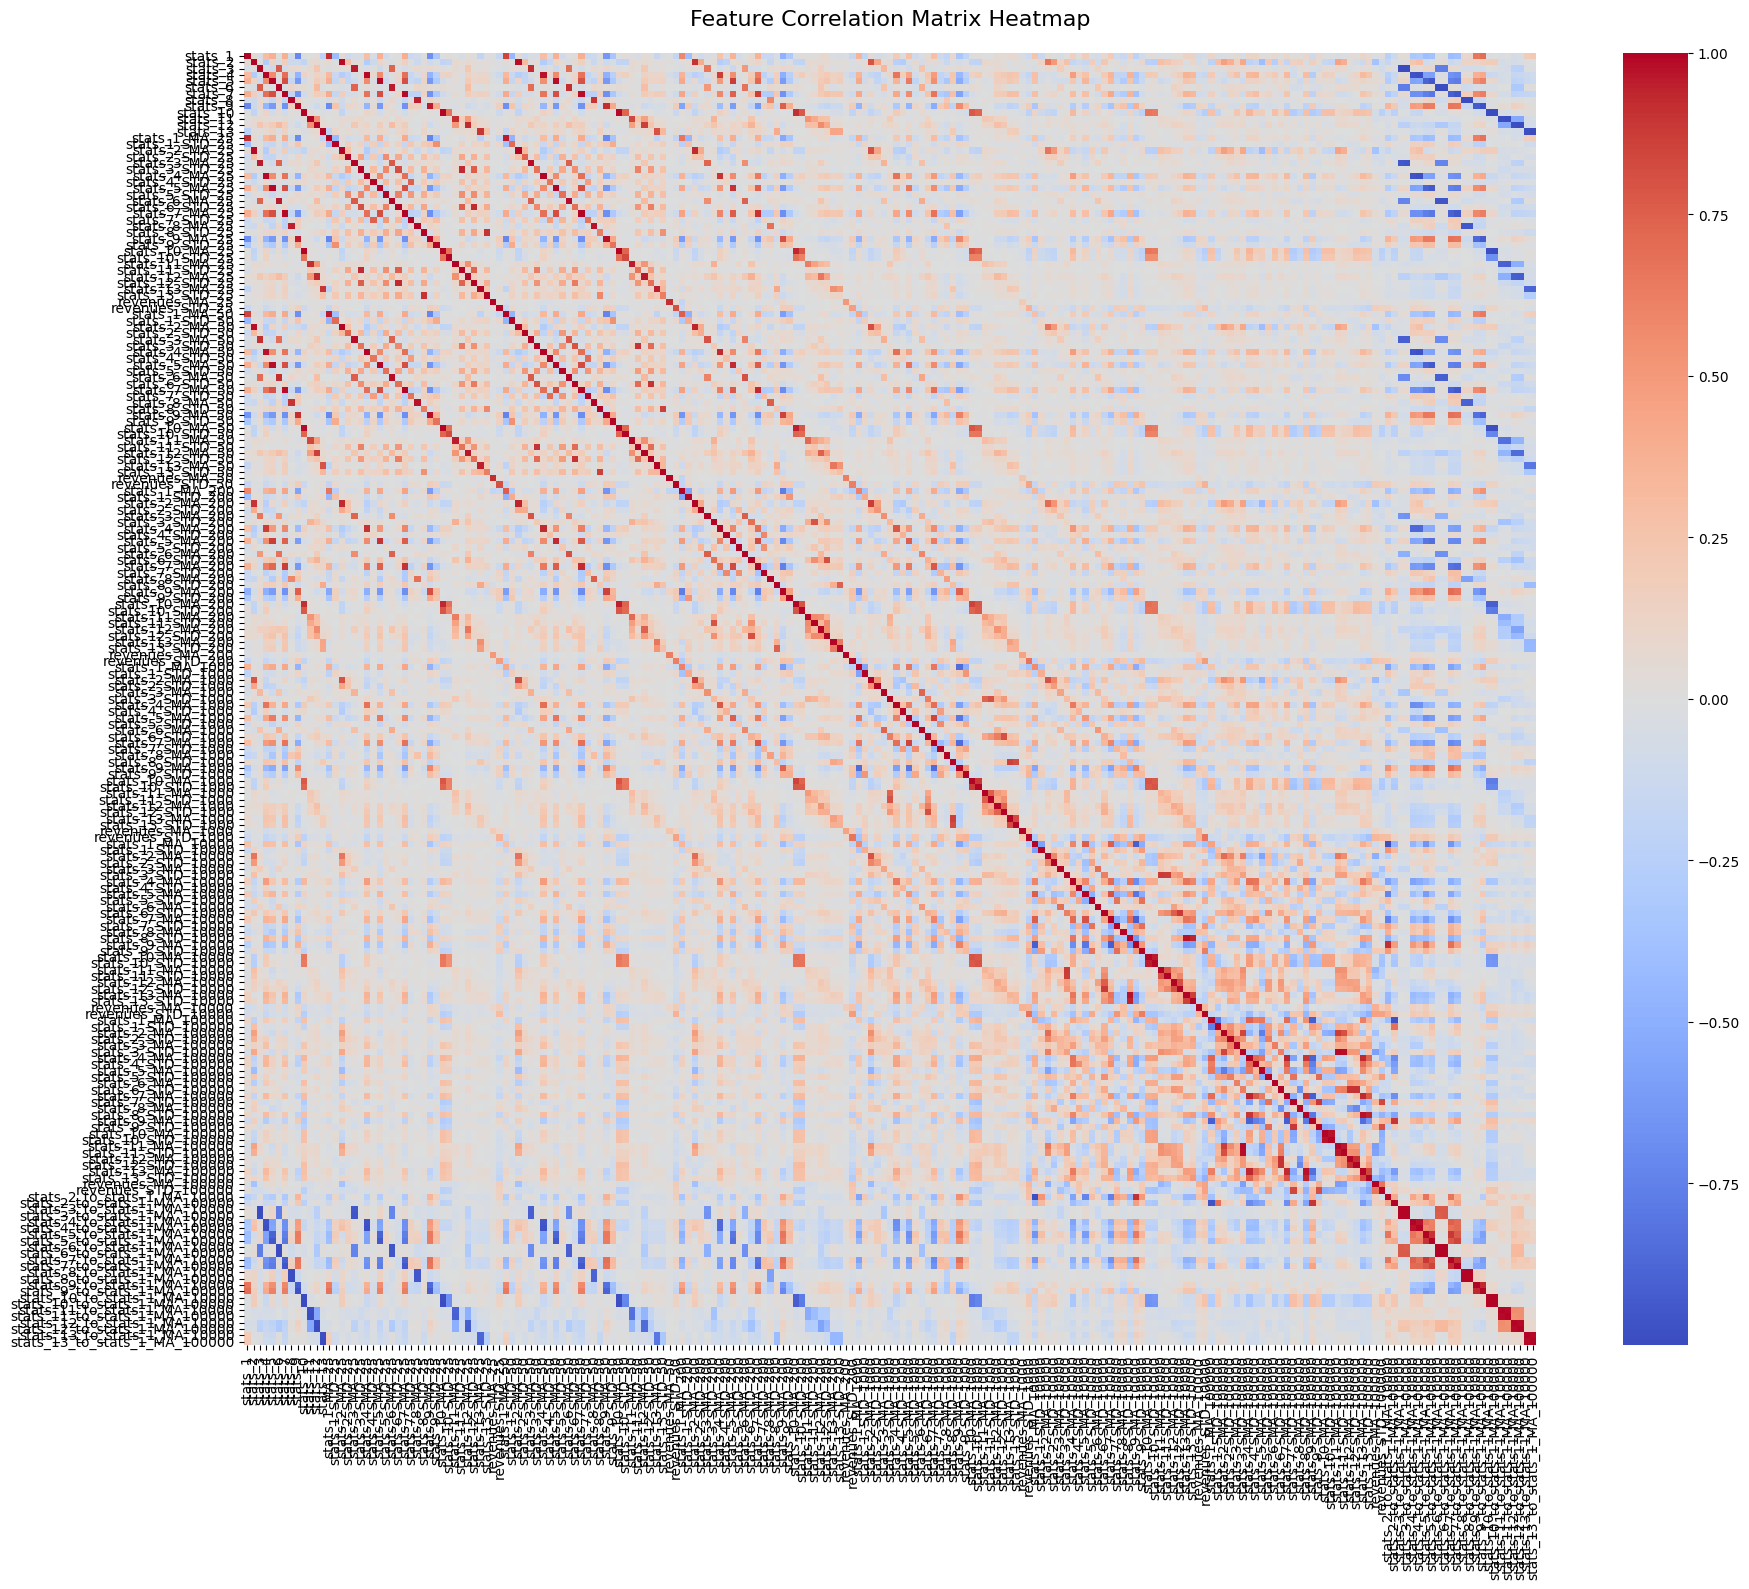


Strongest correlations (|correlation| > 0.8):
stats_1 -- stats_1_MA_25: 0.915
stats_1 -- stats_1_MA_50: 0.845
stats_2 -- stats_2_MA_25: 0.992
stats_2 -- stats_2_MA_50: 0.981
stats_2 -- stats_2_MA_200: 0.905
stats_3 -- stats_3_MA_25: 0.956
stats_3 -- stats_3_MA_50: 0.913
stats_3 -- stats_3_to_stats_1_MA_10000: -0.995
stats_3 -- stats_3_to_stats_1_MA_100000: -0.998
stats_4 -- stats_4_MA_25: 0.990
stats_4 -- stats_4_MA_50: 0.976
stats_4 -- stats_4_MA_200: 0.871
stats_4 -- stats_4_to_stats_1_MA_10000: -0.975
stats_4 -- stats_4_to_stats_1_MA_100000: -0.992
stats_5 -- stats_7: 0.818
stats_5 -- stats_5_MA_25: 0.992
stats_5 -- stats_7_MA_25: 0.811
stats_5 -- stats_5_MA_50: 0.979
stats_5 -- stats_7_MA_50: 0.802
stats_5 -- stats_5_MA_200: 0.873
stats_5 -- stats_5_to_stats_1_MA_10000: -0.897
stats_5 -- stats_5_to_stats_1_MA_100000: -0.951
stats_6 -- stats_6_MA_25: 0.959
stats_6 -- stats_6_MA_50: 0.919
stats_6 -- stats_6_to_stats_1_MA_10000: -0.994
stats_6 -- stats_6_to_stats_1_MA_100000: -0.998


In [70]:
# Set up the matplotlib figure size
plt.figure(figsize=(20, 16))

# Calculate correlation matrix
corr_matrix = X_training.corr()

# Create heatmap
sns.heatmap(corr_matrix, 
            cmap='coolwarm',  # Color scheme: red for positive correlations, blue for negative
            center=0,         # Center the colormap at 0
            annot=False,      # Don't show individual values (too many features)
            square=True,      # Make the plot square-shaped
            xticklabels=True, 
            yticklabels=True)

# Customize the plot
plt.title('Feature Correlation Matrix Heatmap', pad=20, size=16)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

# Optional: Print the strongest correlations
threshold = 0.8  # You can adjust this threshold
strong_corr = np.where(np.abs(corr_matrix) > threshold)
strong_corr = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y]) 
               for x, y in zip(*strong_corr) if x != y]

if strong_corr:
    print("\nStrongest correlations (|correlation| > {}):".format(threshold))
    for feat1, feat2, corr in strong_corr:
        print(f"{feat1} -- {feat2}: {corr:.3f}")

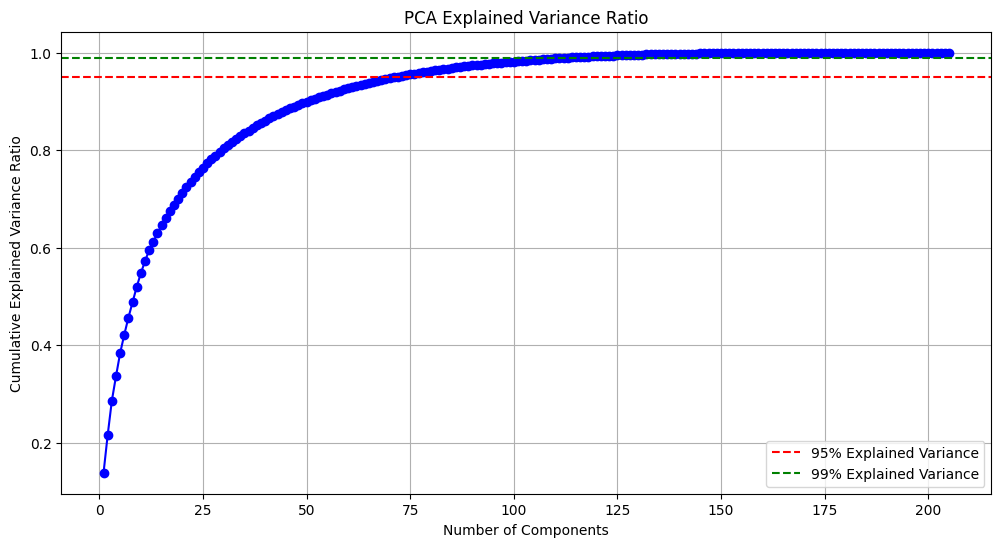

Number of components needed for 95% variance: 72
Number of components needed for 99% variance: 114

Top 10 components explained variance ratio:
PC1: 0.1384 (0.1384 cumulative)
PC2: 0.0776 (0.2160 cumulative)
PC3: 0.0700 (0.2860 cumulative)
PC4: 0.0503 (0.3363 cumulative)
PC5: 0.0474 (0.3837 cumulative)
PC6: 0.0379 (0.4216 cumulative)
PC7: 0.0350 (0.4566 cumulative)
PC8: 0.0319 (0.4885 cumulative)
PC9: 0.0311 (0.5196 cumulative)
PC10: 0.0280 (0.5477 cumulative)

Top feature contributions for first 3 principal components:

Principal Component 1:
stats_7_to_stats_1_MA_10000: 0.1661
stats_7_to_stats_1_MA_100000: 0.1590
stats_5_to_stats_1_MA_10000: 0.1569
stats_4_to_stats_1_MA_10000: 0.1512
stats_7_MA_50: -0.1510

Principal Component 2:
stats_10_MA_50: 0.1824
stats_10_MA_200: 0.1824
stats_10_MA_25: 0.1819
stats_10: 0.1812
stats_10_to_stats_1_MA_100000: -0.1807

Principal Component 3:
stats_11_MA_100000: 0.1779
stats_3_STD_100000: 0.1743
stats_11_STD_100000: 0.1713
stats_2_MA_100000: 0.1540


In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 标准化数据
scaler = StandardScaler()
X_training_scaled = scaler.fit_transform(X_training)
X_testing_scaled = scaler.transform(X_testing)

# 2. 执行PCA
pca = PCA()
X_training_pca = pca.fit_transform(X_training_scaled)

# 3. 分析解释方差比
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# 绘制解释方差比图
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance_ratio, 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')
plt.grid(True)

# 添加95%和99%的参考线
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% Explained Variance')
plt.legend()
plt.show()

# 找到解释95%和99%方差所需的组件数
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance_ratio >= 0.99) + 1

print(f"Number of components needed for 95% variance: {n_components_95}")
print(f"Number of components needed for 99% variance: {n_components_99}")

# 显示前10个主成分的方差解释比
print("\nTop 10 components explained variance ratio:")
for i, ratio in enumerate(explained_variance_ratio[:10], 1):
    print(f"PC{i}: {ratio:.4f} ({cumulative_variance_ratio[i-1]:.4f} cumulative)")

# 4. 使用95%方差的组件数重新拟合PCA
pca_95 = PCA(n_components=n_components_95)
X_training_pca_95 = pca_95.fit_transform(X_training_scaled)
X_testing_pca_95 = pca_95.transform(X_testing_scaled)

# 5. 查看主要特征的贡献
feature_names = X_training.columns
top_components = 3  # 显示前3个主成分

print(f"\nTop feature contributions for first {top_components} principal components:")
for i in range(top_components):
    pc = pca_95.components_[i]
    top_features_idx = np.abs(pc).argsort()[-5:][::-1]  # 每个主成分的前5个最重要特征
    print(f"\nPrincipal Component {i+1}:")
    for idx in top_features_idx:
        print(f"{feature_names[idx]}: {pc[idx]:.4f}")

# 保存转换后的数据
X_train_pca = pd.DataFrame(
    X_training_pca_95, 
    columns=[f'PC{i+1}' for i in range(n_components_95)]
)
X_test_pca = pd.DataFrame(
    X_testing_pca_95, 
    columns=[f'PC{i+1}' for i in range(n_components_95)]
)

print(f"\nTransformed shape:")
print(f"Training set: {X_train_pca.shape}")
print(f"Testing set: {X_test_pca.shape}")

X_training = X_train_pca
X_testing = X_test_pca

In [72]:
# import lightgbm as lgb
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_squared_error, r2_score
# import numpy as np

# params = {
#     'objective': 'regression',
#     'metric': 'rmse',
#     'boosting_type': 'gbdt',
#     'num_leaves': 10,
#     'max_depth': 3,
#     'learning_rate': 0.03,

#     'feature_fraction': 0.7,
#     'bagging_fraction': 0.7,
#     'bagging_freq': 5,

#     'min_data_in_leaf': 50,
#     'lambda_l1': 0.1,
#     'lambda_l2': 1.0,

#     'verbose': -1
# }


# # 2. 创建时间序列交叉验证对象
# tscv = TimeSeriesSplit(n_splits=5)

# # 3. 进行交叉验证训练
# cv_scores = []
# feature_importance_list = []

# for fold, (train_idx, val_idx) in enumerate(tscv.split(X_training), 1):
#     print(f"\nFold {fold}")
    
#     # 准备训练和验证数据
#     X_train_fold = X_training.iloc[train_idx]
#     y_train_fold = y_training.iloc[train_idx]
#     X_val_fold = X_training.iloc[val_idx]
#     y_val_fold = y_training.iloc[val_idx]
    
#     # 创建LightGBM数据集
#     train_data = lgb.Dataset(X_train_fold, label=y_train_fold)
#     val_data = lgb.Dataset(X_val_fold, label=y_val_fold)
    
#     # 训练模型
#     model = lgb.train(
#         params,
#         train_data,
#         num_boost_round=1000,
#         valid_sets=[train_data, val_data],
#         callbacks=[lgb.early_stopping(50)],
#         valid_names=['train', 'valid']
#     )
    
#     # 记录验证集上的性能
#     val_pred = model.predict(X_val_fold)
#     mse = mean_squared_error(y_val_fold, val_pred)
#     r2 = r2_score(y_val_fold, val_pred)
#     cv_scores.append({
#         'fold': fold,
#         'rmse': np.sqrt(mse),
#         'r2': r2
#     })
    
#     # 记录特征重要性
#     feature_importance = pd.DataFrame({
#         'feature': X_training.columns,
#         'importance': model.feature_importance('gain')
#     })
#     feature_importance_list.append(feature_importance)

# # 4. 打印交叉验证结果
# print("\nCross-validation Results:")
# cv_df = pd.DataFrame(cv_scores)
# print(cv_df)
# print("\nMean RMSE:", cv_df['rmse'].mean())
# print("Std RMSE:", cv_df['rmse'].std())
# print("Mean R2:", cv_df['r2'].mean())

# # 5. 在完整训练集上训练最终模型
# final_train_data = lgb.Dataset(X_training, label=y_training)
# final_model = lgb.train(
#     params,
#     final_train_data,
#     num_boost_round=1000,
#     valid_sets=[final_train_data],
#     callbacks=[lgb.early_stopping(50)]
# )

# # 6. 分析特征重要性
# final_importance = pd.DataFrame({
#     'feature': X_training.columns,
#     'importance': final_model.feature_importance('gain')
# })
# final_importance = final_importance.sort_values('importance', ascending=False)

# # 绘制特征重要性图
# plt.figure(figsize=(12, 6))
# plt.bar(range(len(final_importance[:20])), final_importance['importance'][:20])
# plt.xticks(range(len(final_importance[:20])), final_importance['feature'][:20], rotation=45, ha='right')
# plt.title('Top 20 Feature Importance')
# plt.tight_layout()
# plt.show()

# # 7. 在测试集上进行预测和评估
# test_predictions = final_model.predict(X_testing)
# test_mse = mean_squared_error(y_testing, test_predictions)
# test_r2 = r2_score(y_testing, test_predictions)

# print("\nTest Set Performance:")
# print(f"RMSE: {np.sqrt(test_mse):.6f}")
# print(f"R2 Score: {test_r2:.6f}")

# # 8. 绘制预测值与实际值的对比图
# plt.figure(figsize=(15, 6))
# plt.plot(y_testing.values[:1000], label='Actual', alpha=0.7)
# plt.plot(test_predictions[:1000], label='Predicted', alpha=0.7)
# plt.title('Actual vs Predicted Values (First 1000 Samples)')
# plt.legend()
# plt.grid(True)
# plt.show()

# # 9. 分析预测误差
# errors = y_testing - test_predictions
# plt.figure(figsize=(12, 6))
# plt.hist(errors, bins=50, density=True, alpha=0.7)
# plt.title('Prediction Error Distribution')
# plt.xlabel('Error')
# plt.ylabel('Density')
# plt.grid(True)
# plt.show()

# print("\nError Statistics:")
# print(f"Mean Error: {errors.mean():.6f}")
# print(f"Error Std: {errors.std():.6f}")
# print(f"Error MAD: {np.median(np.abs(errors)):.6f}")

# # 10. 保存模型（可选）
# final_model.save_model('lightgbm_revenue_predictor.txt')

In [73]:

# stats = calculate_direction_accuracy(y_testing, test_predictions)

# print_direction_stats(stats)

# stats = calculate_direction_accuracy(y_training, train_predictions)

# print_direction_stats(stats)

In [74]:

# # 7. 在测试集上进行预测和评估
# train_predictions = final_model.predict(X_training)
# train_mse = mean_squared_error(y_training, train_predictions)
# train_r2 = r2_score(y_training, train_predictions)

# print("\nTest Set Performance:")
# print(f"RMSE: {np.sqrt(train_mse):.6f}")
# print(f"R2 Score: {train_r2:.6f}")

# # 8. 绘制预测值与实际值的对比图
# plt.figure(figsize=(15, 6))
# plt.plot(y_training.values[:10000], label='Actual', alpha=0.7)
# plt.plot(train_predictions[:10000], label='Predicted', alpha=0.7)
# plt.title('Actual vs Predicted Values (First 1000 Samples)')
# plt.legend()
# plt.grid(True)
# plt.show()

# # 9. 分析预测误差
# errors = y_training - train_predictions
# plt.figure(figsize=(12, 6))
# plt.hist(errors, bins=50, density=True, alpha=0.7)
# plt.title('Prediction Error Distribution')
# plt.xlabel('Error')
# plt.ylabel('Density')
# plt.grid(True)
# plt.show()

# print("\nError Statistics:")
# print(f"Mean Error: {errors.mean():.6f}")
# print(f"Error Std: {errors.std():.6f}")
# print(f"Error MAD: {np.median(np.abs(errors)):.6f}")



In [75]:
def calculate_direction_accuracy(y_true, y_pred):
    """
    计算预测值方向的准确性和混淆矩阵
    
    参数:
    y_true: array-like, 实际值
    y_pred: array-like, 预测值
    
    返回:
    dict: 详细统计信息
    """
    # 确保输入为numpy数组
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 计算符号
    true_signs = np.sign(y_true)
    pred_signs = np.sign(y_pred)
    
    # 计算混淆矩阵统计
    pred_positive = (pred_signs > 0)
    pred_negative = (pred_signs < 0)
    true_positive = (true_signs > 0)
    true_negative = (true_signs < 0)
    
    # 当预测为正时的统计
    pred_pos_count = pred_positive.sum()
    pred_pos_correct = np.logical_and(pred_positive, true_positive).sum()
    pred_pos_wrong = np.logical_and(pred_positive, true_negative).sum()
    
    # 当预测为负时的统计
    pred_neg_count = pred_negative.sum()
    pred_neg_correct = np.logical_and(pred_negative, true_negative).sum()
    pred_neg_wrong = np.logical_and(pred_negative, true_positive).sum()
        # 计算各种情况下的平均收益
    pred_pos_mean_return = y_true[pred_positive].mean() if pred_pos_count > 0 else 0
    pred_neg_mean_return = y_true[pred_negative].mean() if pred_neg_count > 0 else 0
    
    # 计算预测正确时的平均收益
    pred_pos_correct_mean = y_true[np.logical_and(pred_positive, true_positive)].mean() if pred_pos_correct > 0 else 0
    pred_pos_wrong_mean = y_true[np.logical_and(pred_positive, true_negative)].mean() if pred_pos_wrong > 0 else 0
    pred_neg_correct_mean = y_true[np.logical_and(pred_negative, true_negative)].mean() if pred_neg_correct > 0 else 0
    pred_neg_wrong_mean = y_true[np.logical_and(pred_negative, true_positive)].mean() if pred_neg_wrong > 0 else 0
    
    stats = {
        'total_samples': len(y_true),
        # 预测为正的统计
        'predicted_positive': pred_pos_count,
        'predicted_positive_actually_positive': pred_pos_correct,
        'predicted_positive_actually_negative': pred_pos_wrong,
        'predicted_positive_accuracy': pred_pos_correct / pred_pos_count if pred_pos_count > 0 else 0,
        'predicted_positive_mean_return': pred_pos_mean_return,
        'predicted_positive_correct_mean': pred_pos_correct_mean,
        'predicted_positive_wrong_mean': pred_pos_wrong_mean,
        
        # 预测为负的统计
        'predicted_negative': pred_neg_count,
        'predicted_negative_actually_negative': pred_neg_correct,
        'predicted_negative_actually_positive': pred_neg_wrong,
        'predicted_negative_accuracy': pred_neg_correct / pred_neg_count if pred_neg_count > 0 else 0,
        'predicted_negative_mean_return': pred_neg_mean_return,
        'predicted_negative_correct_mean': pred_neg_correct_mean,
        'predicted_negative_wrong_mean': pred_neg_wrong_mean,
    }
    
    return stats

# 使用函数评估预测结果

def print_direction_stats(stats):
    print("方向预测性能评估:")
    print(f"样本总数: {stats['total_samples']}")
    
    print("\n预测为正的情况:")
    print(f"预测为正的样本数: {stats['predicted_positive']}")
    print(f"  实际为正: {stats['predicted_positive_actually_positive']}")
    print(f"  实际为负: {stats['predicted_positive_actually_negative']}")
    print(f"  准确率: {stats['predicted_positive_accuracy']:.4f}")
    print(f"  平均收益: {stats['predicted_positive_mean_return']:.6f}")
    print(f"  预测正确时平均收益: {stats['predicted_positive_correct_mean']:.6f}")
    print(f"  预测错误时平均收益: {stats['predicted_positive_wrong_mean']:.6f}")
    
    print("\n预测为负的情况:")
    print(f"预测为负的样本数: {stats['predicted_negative']}")
    print(f"  实际为负: {stats['predicted_negative_actually_negative']}")
    print(f"  实际为正: {stats['predicted_negative_actually_positive']}")
    print(f"  准确率: {stats['predicted_negative_accuracy']:.4f}")
    print(f"  平均收益: {stats['predicted_negative_mean_return']:.6f}")
    print(f"  预测正确时平均收益: {stats['predicted_negative_correct_mean']:.6f}")
    print(f"  预测错误时平均收益: {stats['predicted_negative_wrong_mean']:.6f}")
    
    total_correct = (stats['predicted_positive_actually_positive'] + 
                    stats['predicted_negative_actually_negative'])
    print(f"\n总体准确率: {total_correct / stats['total_samples']:.4f}")

# stats = calculate_direction_accuracy(y_testing, test_predictions)

# print_direction_stats(stats)

In [76]:

# # 使用函数评估预测结果
# stats = calculate_direction_accuracy(y_training, train_predictions)
# print_direction_stats(stats)

In [77]:
# y_training
# y_testing
# train_predictions 
# test_predictions

In [78]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # ===============================================
# # 1) 计算 train 的 80% 分位阈值
# # ===============================================
# thr_80 = np.percentile(train_predictions, 80)
# print("80% percentile threshold (train) =", thr_80)

# # ===============================================
# # 2) 构建策略信号
# # ===============================================
# train_signal = (train_predictions > thr_80).astype(int)   # 1 = long, 0 = flat
# test_signal  = (test_predictions  > thr_80).astype(int)   # ✅ Test 沿用 train 阈值

# # ===============================================
# # 3) 计算策略收益
# # ===============================================
# train_strat_ret = train_signal * y_training
# test_strat_ret  = test_signal  * y_testing

# train_cum = train_strat_ret.cumsum()
# test_cum  = test_strat_ret.cumsum()

# train_bh = y_training.cumsum()
# test_bh  = y_testing.cumsum()

# # ===============================================
# # 4) Plot 双子图
# # ===============================================
# fig, axs = plt.subplots(2, 1, figsize=(13,10), sharex=False)

# # ----- Train -----
# axs[0].plot(train_cum, label="Train Strategy (>80% Long)")
# axs[0].plot(train_bh, label="Train Buy & Hold", linestyle='--')
# axs[0].axhline(0, color="gray", linestyle=":")
# axs[0].set_title("Train Cumulative Returns")
# axs[0].legend()
# axs[0].grid(True)

# # ----- Test -----
# axs[1].plot(test_cum, label="Test Strategy (>80% Long)")
# axs[1].plot(test_bh, label="Test Buy & Hold", linestyle='--')
# axs[1].axhline(0, color="gray", linestyle=":")
# axs[1].set_title("Test Cumulative Returns")
# axs[1].legend()
# axs[1].grid(True)

# plt.tight_layout()
# plt.show()

# # ===============================================
# # 5) Summary stats
# # ===============================================
# print("====== Train ======")
# print("Total Strategy Return:", train_cum.iloc[-1])
# print("Total Buy&Hold Return:", train_bh.iloc[-1])
# print("Hit Rate:", (train_signal > 0).mean())
# print("Trades:", train_signal.sum())

# print("\n====== Test ======")
# print("Total Strategy Return:", test_cum.iloc[-1])
# print("Total Buy&Hold Return:", test_bh.iloc[-1])
# print("Hit Rate:", (test_signal > 0).mean())
# print("Trades:", test_signal.sum())
# # ===============================================
# # 6) 统计策略信号非0的收益分布
# # ===============================================
# train_nonzero_mean = train_strat_ret[train_strat_ret != 0].mean()
# test_nonzero_mean  = test_strat_ret[test_strat_ret != 0].mean()

# print("\nAverage strategy return (train, only trades):", train_nonzero_mean)
# print("Average strategy return (test, only trades):",  test_nonzero_mean)

# # 可选：统计非0交易数量
# train_trades = (train_strat_ret != 0).sum()
# test_trades  = (test_strat_ret != 0).sum()
# print("Number of trades (train):", train_trades)
# print("Number of trades (test):", test_trades)


In [79]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------
# ✅ 假设：X_training, y_training 已经定义好
# ---------------------------------------------------

# ====== TimeSeriesSplit ======
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = []
models = []
scalers = []

# for fold, (train_idx, val_idx) in enumerate(tscv.split(X_training), 1):
#     print(f"\n========== Fold {fold} ==========")

#     X_train_fold = X_training.iloc[train_idx]
#     y_train_fold = y_training.iloc[train_idx]
#     X_val_fold   = X_training.iloc[val_idx]
#     y_val_fold   = y_training.iloc[val_idx]

#     # ✅ 每 fold 内 fit scaler
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train_fold)
#     X_val_scaled   = scaler.transform(X_val_fold)

#     # ✅ Ridge
#     model = Ridge(alpha=100.0)
#     # model = LinearSVR(C=1.0, epsilon=0.1, max_iter=5000)

#     model.fit(X_train_scaled, y_train_fold)

#     val_pred = model.predict(X_val_scaled)

#     mse = mean_squared_error(y_val_fold, val_pred)
#     r2  = r2_score(y_val_fold, val_pred)

#     cv_scores.append({
#         "fold": fold,
#         "rmse": np.sqrt(mse),
#         "r2": r2
#     })

#     models.append(model)
#     scalers.append(scaler)

# # ===== CV 结果 =====
# cv_df = pd.DataFrame(cv_scores)
# print("\nCross-validation Results:")
# print(cv_df)
# print("\nMean RMSE:", cv_df['rmse'].mean())
# print("Std RMSE:", cv_df['rmse'].std())
# print("Mean R2:", cv_df['r2'].mean())


# ================================
# ✅ 最终模型：使用全部 training 数据训练
# ================================
final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_training)

final_model = Ridge(alpha=1000.0)
# final_model = LinearSVR(C=0.1, epsilon=0.5, max_iter=5000)


final_model.fit(X_train_scaled, y_training)

print("\n✅ Final Ridge model trained")



# ================================
# ✅ 训练集预测并评估方向
# ================================
train_predictions = final_model.predict(X_train_scaled)
train_stats = calculate_direction_accuracy(y_training, train_predictions)

print_direction_stats(train_stats)

# ================================
# ✅ 测试集预测并评估方向
# ================================
# *要用 final_scaler.transform*
X_test_scaled = final_scaler.transform(X_testing)
test_predictions = final_model.predict(X_test_scaled)

test_stats = calculate_direction_accuracy(y_testing, test_predictions)
print_direction_stats(test_stats)


✅ Final Ridge model trained
方向预测性能评估:
样本总数: 739202

预测为正的情况:
预测为正的样本数: 448036
  实际为正: 228859
  实际为负: 219177
  准确率: 0.5108
  平均收益: 0.680032
  预测正确时平均收益: 7.132681
  预测错误时平均收益: -6.057659

预测为负的情况:
预测为负的样本数: 291166
  实际为负: 158010
  实际为正: 133154
  准确率: 0.5427
  平均收益: -0.530591
  预测正确时平均收益: -6.085167
  预测错误时平均收益: 6.060856

总体准确率: 0.5234
方向预测性能评估:
样本总数: 300000

预测为正的情况:
预测为正的样本数: 172889
  实际为正: 84702
  实际为负: 88184
  准确率: 0.4899
  平均收益: 0.253222
  预测正确时平均收益: 8.939607
  预测错误时平均收益: -8.090168

预测为负的情况:
预测为负的样本数: 127111
  实际为负: 62508
  实际为正: 64603
  准确率: 0.4918
  平均收益: 0.519928
  预测正确时平均收益: -7.779634
  预测错误时平均收益: 8.550344

总体准确率: 0.4907


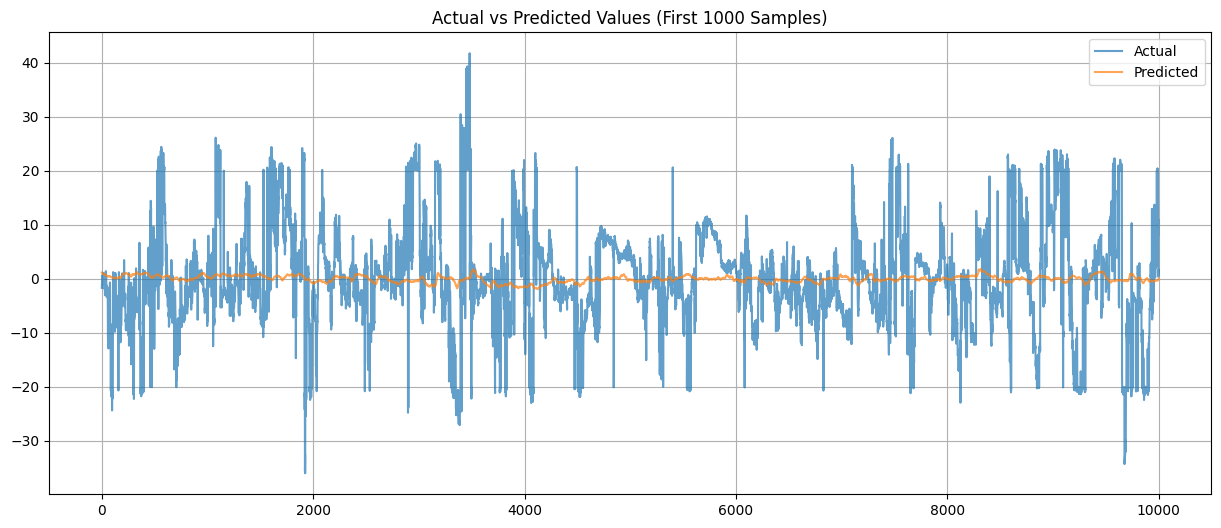

In [80]:
# 8. 绘制预测值与实际值的对比图
plt.figure(figsize=(15, 6))
plt.plot(y_training.values[:10000], label='Actual', alpha=0.7)
plt.plot(train_predictions[:10000], label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Values (First 1000 Samples)')
plt.legend()
plt.grid(True)
plt.show()

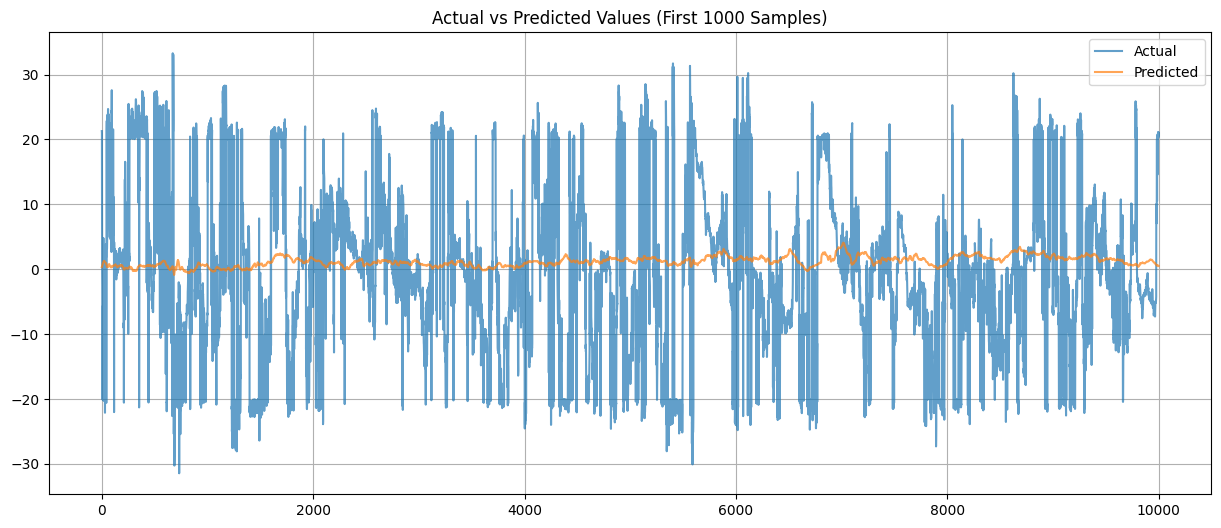

In [81]:
# 8. 绘制预测值与实际值的对比图
plt.figure(figsize=(15, 6))
plt.plot(y_testing.values[:10000], label='Actual', alpha=0.7)
plt.plot(test_predictions[:10000], label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Values (First 1000 Samples)')
plt.legend()
plt.grid(True)
plt.show()

In [82]:
# y_training
# y_testing
# train_predictions 
# test_predictions



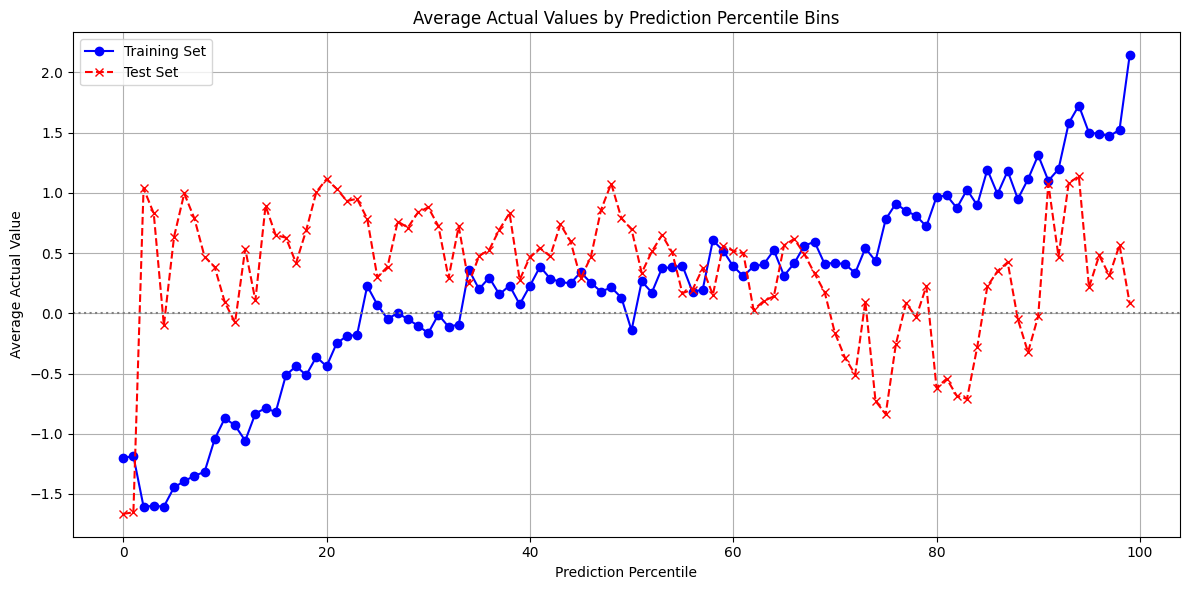


Bin Statistics:
Percentile   Train Mean    Test Mean
-----------------------------------
       0.0    -1.200262    -1.664595
       1.0    -1.185374    -1.653055
       2.0    -1.605027     1.037480
       3.0    -1.599388     0.829740
       4.0    -1.604418    -0.099480
       5.0    -1.444561     0.635048
       6.0    -1.394645     0.994714
       7.0    -1.348575     0.787546
       8.0    -1.317138     0.470606
       9.0    -1.043456     0.383078
      10.0    -0.870556     0.089940
      11.0    -0.931282    -0.076370
      12.0    -1.057609     0.535955
      13.0    -0.831995     0.107521
      14.0    -0.787616     0.892703
      15.0    -0.819949     0.648672
      16.0    -0.514410     0.628191
      17.0    -0.438875     0.417451
      18.0    -0.513029     0.689815
      19.0    -0.361363     1.008246
      20.0    -0.440523     1.113866
      21.0    -0.248367     1.032928
      22.0    -0.188523     0.932500
      23.0    -0.179796     0.950578
      24.0     0.22705

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# 计算训练集的分位数边界
percentiles = np.arange(0, 101, 1)  # 5%间隔的分位数
train_bins = np.percentile(train_predictions, percentiles)

# 计算训练集中每个箱子的实际值均值
train_means = []
for i in range(len(train_bins)-1):
    mask = (train_predictions >= train_bins[i]) & (train_predictions < train_bins[i+1])
    bin_mean = y_training[mask].mean()
    train_means.append(bin_mean)

# 使用相同的边界计算测试集中每个箱子的实际值均值
test_means = []
for i in range(len(train_bins)-1):
    mask = (test_predictions >= train_bins[i]) & (test_predictions < train_bins[i+1])
    bin_mean = y_testing[mask].mean()
    test_means.append(bin_mean)

# 创建图表
plt.figure(figsize=(12, 6))
plt.plot(percentiles[:-1], train_means, 'b-', label='Training Set', marker='o')
plt.plot(percentiles[:-1], test_means, 'r--', label='Test Set', marker='x')

plt.xlabel('Prediction Percentile')
plt.ylabel('Average Actual Value')
plt.title('Average Actual Values by Prediction Percentile Bins')
plt.grid(True)
plt.legend()

# 添加水平零线参考
plt.axhline(y=0, color='gray', linestyle=':')

plt.tight_layout()
plt.show()

# 打印一些统计信息
print("\nBin Statistics:")
print(f"{'Percentile':>10} {'Train Mean':>12} {'Test Mean':>12}")
print("-" * 35)
for i in range(len(train_means)):
    print(f"{percentiles[i]:10.1f} {train_means[i]:12.6f} {test_means[i]:12.6f}")

80% percentile threshold (train) = 1.469476909092819


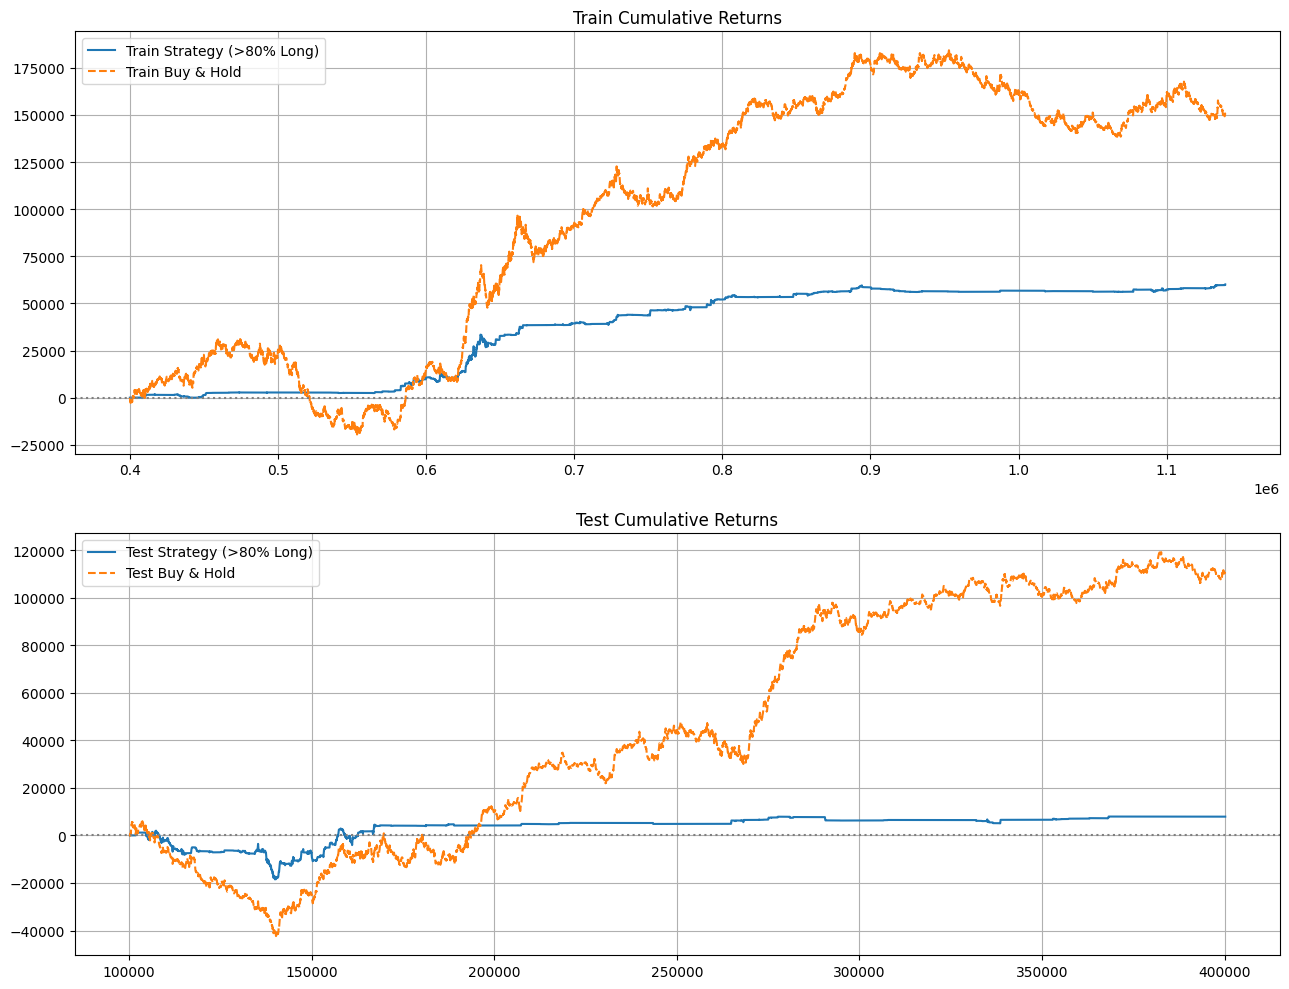

====== Train ======
Total Strategy Return: 60085.61473337731
Total Buy&Hold Return: 150188.77222693842
Hit Rate: 0.05000121752917335
Trades: 36961

====== Test ======
Total Strategy Return: 7890.839435038537
Total Buy&Hold Return: 109867.77954183529
Hit Rate: 0.09116333333333333
Trades: 27349

Average strategy return (train, only trades): 1.6256490553117464
Average strategy return (test, only trades): 0.28852387418328346
Number of trades (train): 36961
Number of trades (test): 27349


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================================
# 1) 计算 train 的 80% 分位阈值
# ===============================================
thr_80 = np.percentile(train_predictions, 95)
# thr_80 = 1
print("80% percentile threshold (train) =", thr_80)

# ===============================================
# 2) 构建策略信号
# ===============================================
train_signal = (train_predictions > thr_80).astype(int)   # 1 = long, 0 = flat
test_signal  = (test_predictions  > thr_80).astype(int)   # ✅ Test 沿用 train 阈值

# ===============================================
# 3) 计算策略收益
# ===============================================
train_strat_ret = train_signal * y_training
test_strat_ret  = test_signal  * y_testing

train_cum = train_strat_ret.cumsum()
test_cum  = test_strat_ret.cumsum()

train_bh = y_training.cumsum()
test_bh  = y_testing.cumsum()

# ===============================================
# 4) Plot 双子图
# ===============================================
fig, axs = plt.subplots(2, 1, figsize=(13,10), sharex=False)

# ----- Train -----
axs[0].plot(train_cum, label="Train Strategy (>80% Long)")
axs[0].plot(train_bh, label="Train Buy & Hold", linestyle='--')
axs[0].axhline(0, color="gray", linestyle=":")
axs[0].set_title("Train Cumulative Returns")
axs[0].legend()
axs[0].grid(True)

# ----- Test -----
axs[1].plot(test_cum, label="Test Strategy (>80% Long)")
axs[1].plot(test_bh, label="Test Buy & Hold", linestyle='--')
axs[1].axhline(0, color="gray", linestyle=":")
axs[1].set_title("Test Cumulative Returns")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# ===============================================
# 5) Summary stats
# ===============================================
print("====== Train ======")
print("Total Strategy Return:", train_cum.iloc[-1])
print("Total Buy&Hold Return:", train_bh.iloc[-1])
print("Hit Rate:", (train_signal > 0).mean())
print("Trades:", train_signal.sum())

print("\n====== Test ======")
print("Total Strategy Return:", test_cum.iloc[-1])
print("Total Buy&Hold Return:", test_bh.iloc[-1])
print("Hit Rate:", (test_signal > 0).mean())
print("Trades:", test_signal.sum())
# ===============================================
# 6) 统计策略信号非0的收益分布
# ===============================================
train_nonzero_mean = train_strat_ret[train_strat_ret != 0].mean()
test_nonzero_mean  = test_strat_ret[test_strat_ret != 0].mean()

print("\nAverage strategy return (train, only trades):", train_nonzero_mean)
print("Average strategy return (test, only trades):",  test_nonzero_mean)

# 可选：统计非0交易数量
train_trades = (train_strat_ret != 0).sum()
test_trades  = (test_strat_ret != 0).sum()
print("Number of trades (train):", train_trades)
print("Number of trades (test):", test_trades)


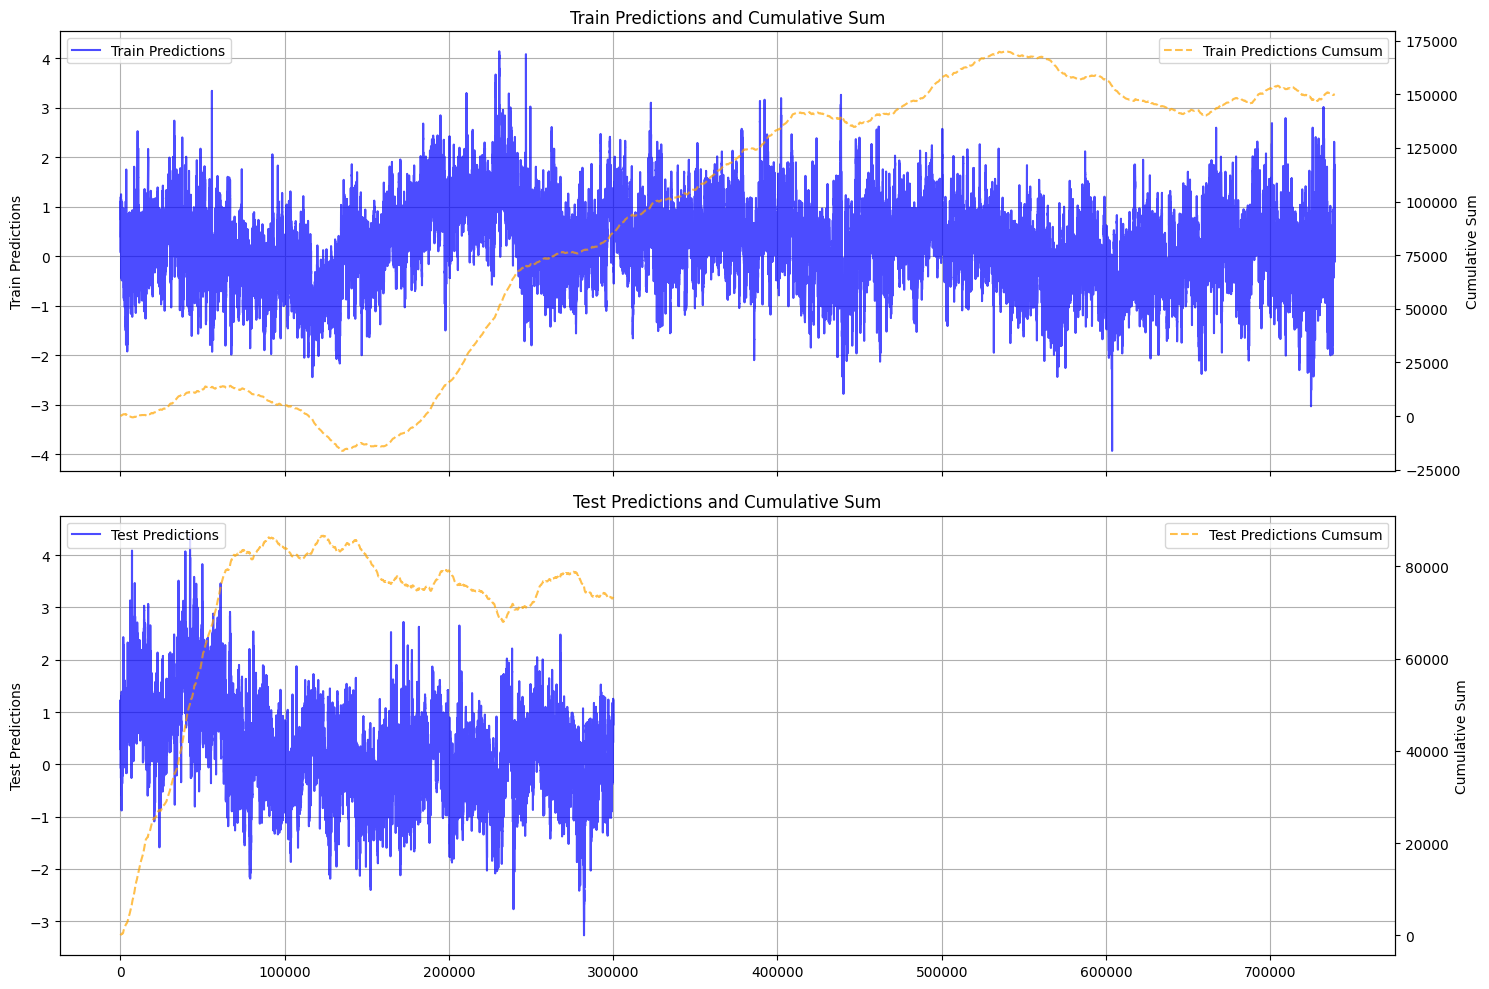

In [85]:
# 绘制 train_predictions 和 test_predictions 及其 cumsum
fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 绘制 train_predictions
ax1 = axs[0]
ax2 = ax1.twinx()
ax1.plot(train_predictions, label='Train Predictions', color='blue', alpha=0.7)
ax2.plot(np.cumsum(train_predictions), label='Train Predictions Cumsum', color='orange', linestyle='--', alpha=0.7)
ax1.set_title('Train Predictions and Cumulative Sum')
ax1.set_ylabel('Train Predictions')
ax2.set_ylabel('Cumulative Sum')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(True)

# 绘制 test_predictions
ax3 = axs[1]
ax4 = ax3.twinx()
ax3.plot(test_predictions, label='Test Predictions', color='blue', alpha=0.7)
ax4.plot(np.cumsum(test_predictions), label='Test Predictions Cumsum', color='orange', linestyle='--', alpha=0.7)
ax3.set_title('Test Predictions and Cumulative Sum')
ax3.set_ylabel('Test Predictions')
ax4.set_ylabel('Cumulative Sum')
ax3.legend(loc='upper left')
ax4.legend(loc='upper right')
ax3.grid(True)

plt.tight_layout()
plt.show()
